In [63]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [3]:
X, y = fetch_openml('mnist_784', return_X_y=True,)
print(X.shape, y.shape)

(70000, 784) (70000,)


In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 418.7 MB


In [5]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 70000 entries, 0 to 69999
Series name: class
Non-Null Count  Dtype   
--------------  -----   
70000 non-null  category
dtypes: category(1)
memory usage: 68.9 KB


In [6]:
y = y.astype(np.uint8)

In [7]:
#scale the pixel values (0–255 )
X_scaled=X/255

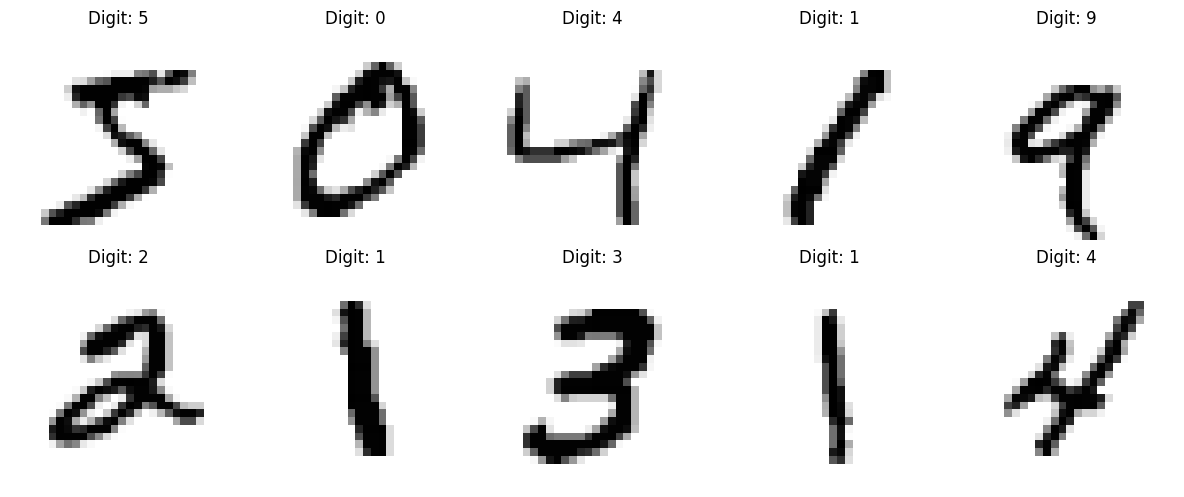

In [8]:
plt.figure(figsize=(12, 5))
for i in range(10):
    image_data = X.iloc[i].values.reshape(28, 28)  # use .iloc[i] + .values
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_data, cmap='gray_r')
    plt.title(f'Digit: {y.iloc[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


In [9]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Sample label values:", np.unique(y))

Training data shape: (49000, 784)
Test data shape: (21000, 784)
Sample label values: [0 1 2 3 4 5 6 7 8 9]


In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred_logreg = log_reg.predict(X_test)

In [13]:
# Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy: {accuracy_logreg:.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2071
           1       0.95      0.97      0.96      2363
           2       0.91      0.90      0.91      2097
           3       0.90      0.89      0.89      2142
           4       0.92      0.91      0.92      2047
           5       0.89      0.87      0.88      1894
           6       0.94      0.95      0.95      2063
           7       0.93      0.94      0.94      2188
           8       0.90      0.88      0.89      2048
           9       0.90      0.89      0.90      2087

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000

Accuracy: 0.9200


# SVM

## kernel='rbf'

In [17]:
svm_rbf= SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
y_pred_svm = svm_rbf.predict(X_test)

In [19]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2071
           1       0.98      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.97      2142
           4       0.98      0.97      0.97      2047
           5       0.98      0.97      0.98      1894
           6       0.98      0.99      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000

SVM Accuracy: 0.9768


## kernel='linear'

In [20]:
svm_linear= SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
y_pred_svm_l = svm_linear.predict(X_test)

In [22]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm_l))

accuracy_svm_l = accuracy_score(y_test, y_pred_svm_l)
print(f"SVM Accuracy: {accuracy_svm_l:.4f}")

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2071
           1       0.96      0.98      0.97      2363
           2       0.92      0.93      0.93      2097
           3       0.90      0.92      0.91      2142
           4       0.93      0.93      0.93      2047
           5       0.91      0.90      0.90      1894
           6       0.96      0.96      0.96      2063
           7       0.95      0.95      0.95      2188
           8       0.93      0.89      0.91      2048
           9       0.93      0.90      0.92      2087

    accuracy                           0.93     21000
   macro avg       0.93      0.93      0.93     21000
weighted avg       0.93      0.93      0.93     21000

SVM Accuracy: 0.9348


## kernel='poly'

In [23]:
svm_poly= SVC(kernel='poly', random_state=42)
svm_poly.fit(X_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
y_pred_svm_p = svm_poly.predict(X_test)

In [25]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm_p))

accuracy_svm_p = accuracy_score(y_test, y_pred_svm_p)
print(f"SVM Accuracy: {accuracy_svm_p:.4f}")

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2071
           1       0.97      0.99      0.98      2363
           2       0.97      0.97      0.97      2097
           3       0.98      0.97      0.97      2142
           4       0.98      0.97      0.97      2047
           5       0.97      0.97      0.97      1894
           6       0.98      0.99      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.98      0.96      0.97      2048
           9       0.97      0.95      0.96      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

SVM Accuracy: 0.9742


#  Decision Tree Classifier

In [26]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
y_pred_dt = dt.predict(X_test)

In [28]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2071
           1       0.94      0.96      0.95      2363
           2       0.84      0.84      0.84      2097
           3       0.81      0.81      0.81      2142
           4       0.87      0.86      0.86      2047
           5       0.82      0.80      0.81      1894
           6       0.91      0.91      0.91      2063
           7       0.90      0.90      0.90      2188
           8       0.80      0.81      0.80      2048
           9       0.84      0.84      0.84      2087

    accuracy                           0.87     21000
   macro avg       0.86      0.86      0.86     21000
weighted avg       0.87      0.87      0.87     21000

Decision Tree Accuracy: 0.8655


# Random Forest Classifier

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = rf.predict(X_test)

In [31]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.98      0.98      0.98      2363
           2       0.96      0.97      0.96      2097
           3       0.96      0.95      0.96      2142
           4       0.97      0.96      0.96      2047
           5       0.97      0.96      0.96      1894
           6       0.97      0.98      0.98      2063
           7       0.97      0.97      0.97      2188
           8       0.95      0.95      0.95      2048
           9       0.94      0.94      0.94      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

Random Forest Accuracy: 0.9662


# XGBoost Classifier

In [36]:
xgb_m = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_m.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [35]:
y_pred_xgb = xgb_m.predict(X_test)

In [37]:
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.99      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.98      2142
           4       0.98      0.96      0.97      2047
           5       0.98      0.97      0.97      1894
           6       0.97      0.98      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

XGBoost Accuracy: 0.9749


# Models Evaluation

In [40]:
accuracy_dict = {
    'Logistic Regression': accuracy_logreg,
    'SVM_rbf': accuracy_svm,
    'SVM_linear': accuracy_svm_l,
    'SVM_poly': accuracy_svm_p,
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf,
    'XGBoost': accuracy_xgb
}
accuracy_df = pd.DataFrame(list(accuracy_dict.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)
print("\nSummary of Model Accuracies:")
print(accuracy_df)


Summary of Model Accuracies:
                 Model  Accuracy
1              SVM_rbf  0.976762
6              XGBoost  0.974905
3             SVM_poly  0.974190
5        Random Forest  0.966190
2           SVM_linear  0.934762
0  Logistic Regression  0.919952
4        Decision Tree  0.865524


# Visualization

C:\Users\admin\AppData\Local\Temp\ipykernel_16496\3499404525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


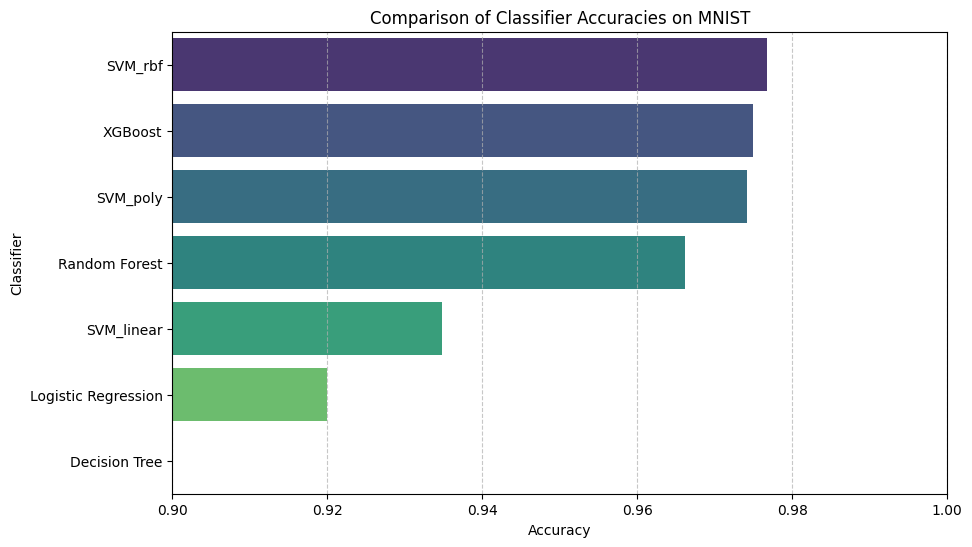

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparison of Classifier Accuracies on MNIST')
plt.xlim(0.90, 1.00)
plt.xlabel('Accuracy')
plt.ylabel('Classifier')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

# Error Analysis

In [52]:
def plot_misclassified_images(X_test, y_test, y_pred, model_name, num_images=8):

    # Identify misclassified indices
    misclassified_indices = np.where(y_test != y_pred)[0]

    # Plot some of them
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(misclassified_indices[:num_images]):
        plt.subplot(2, 4, i+1)
        image = X_test.iloc[idx].values.reshape(28, 28)  # <-- FIXED here
        plt.imshow(image, cmap='gray_r')
        plt.title(f'True: {y_test.iloc[idx]}\nPred: {y_pred[idx]}')  # <-- FIXED here too
        plt.axis('off')

    plt.suptitle(f'{model_name} - Misclassified Samples', fontsize=14)
    plt.tight_layout()
    plt.show()


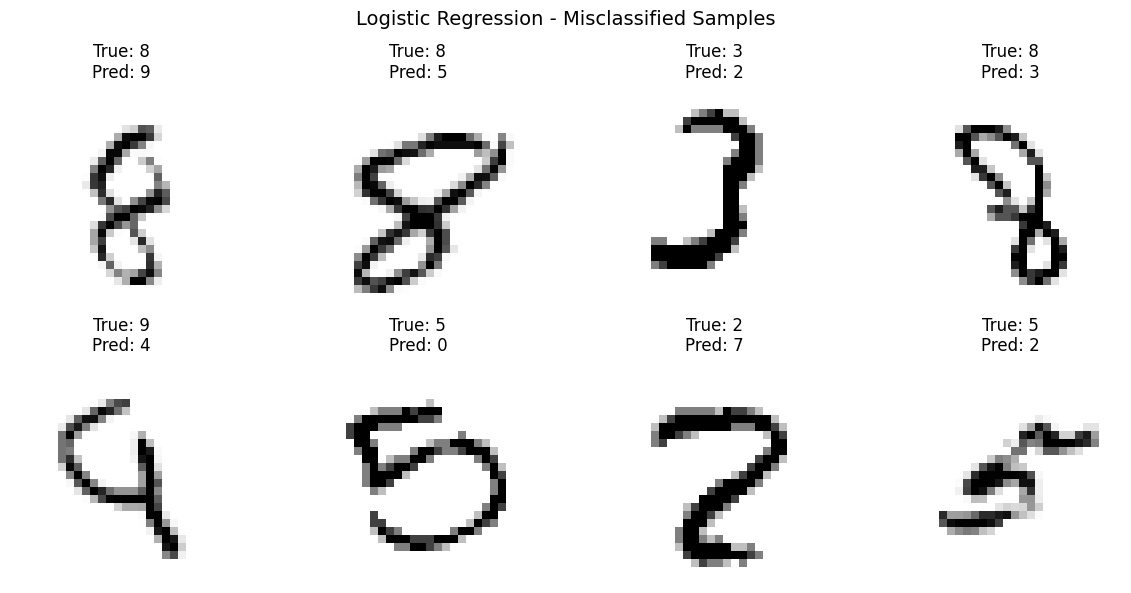

In [56]:
plot_misclassified_images(X_test, y_test, y_pred_logreg, model_name='Logistic Regression')

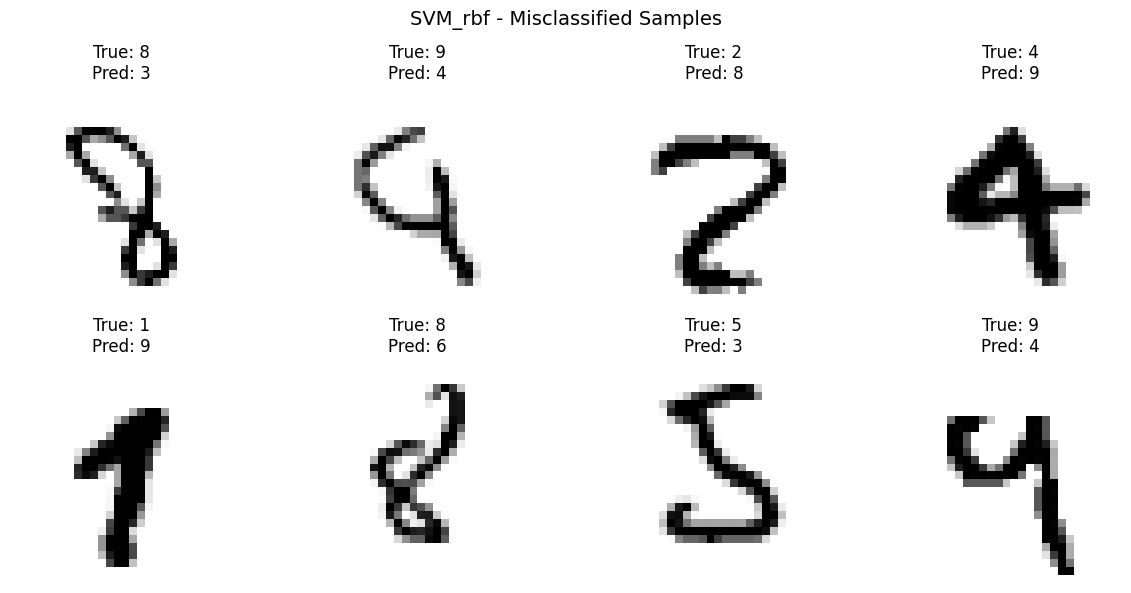

In [60]:
plot_misclassified_images(X_test, y_test, y_pred_svm, model_name='SVM_rbf')

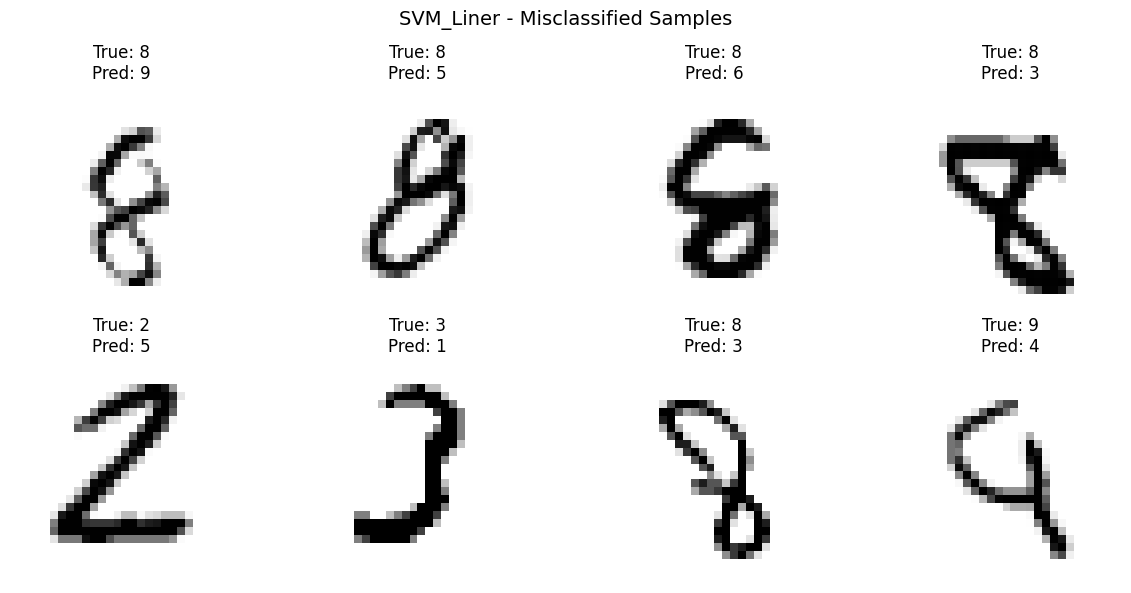

In [61]:
plot_misclassified_images(X_test, y_test, y_pred_svm_l, model_name='SVM_Liner')


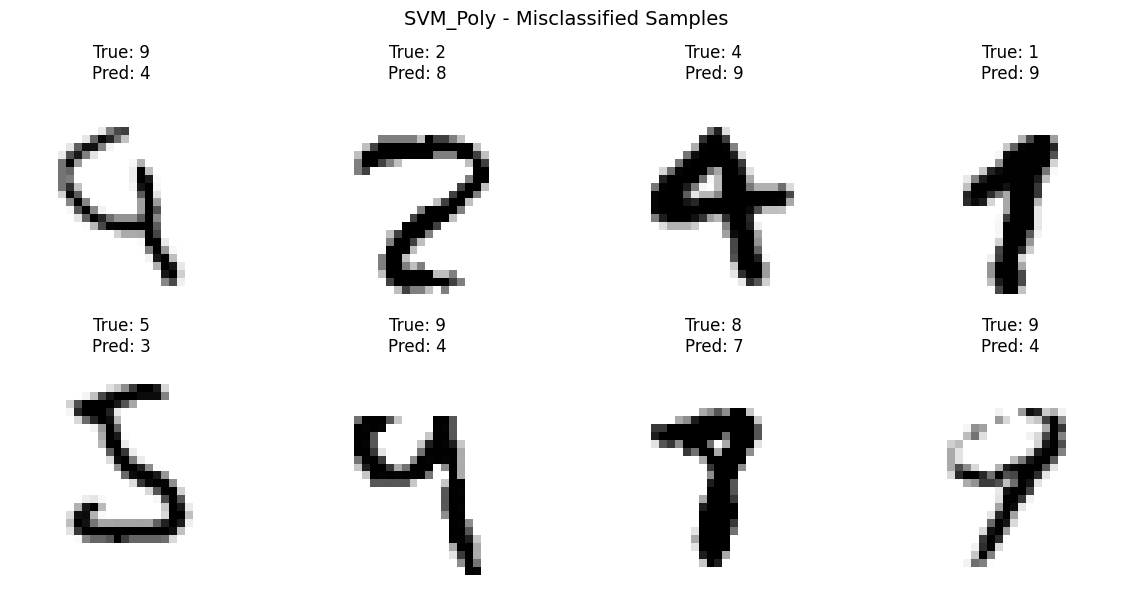

In [62]:
plot_misclassified_images(X_test, y_test, y_pred_svm_p, model_name='SVM_Poly')

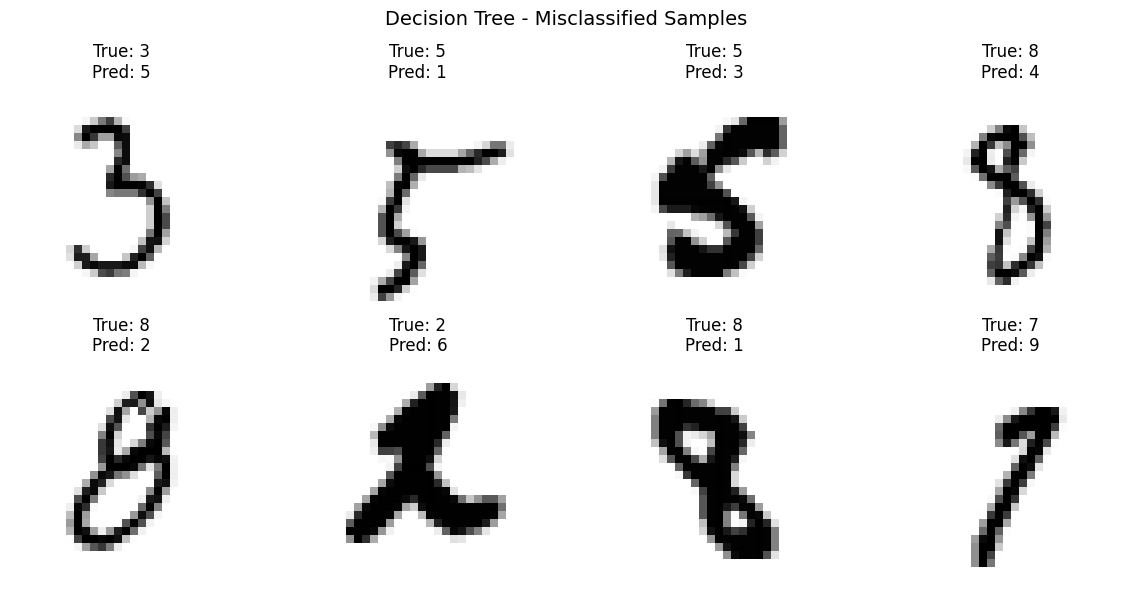

In [57]:
plot_misclassified_images(X_test, y_test, y_pred_dt, model_name='Decision Tree')


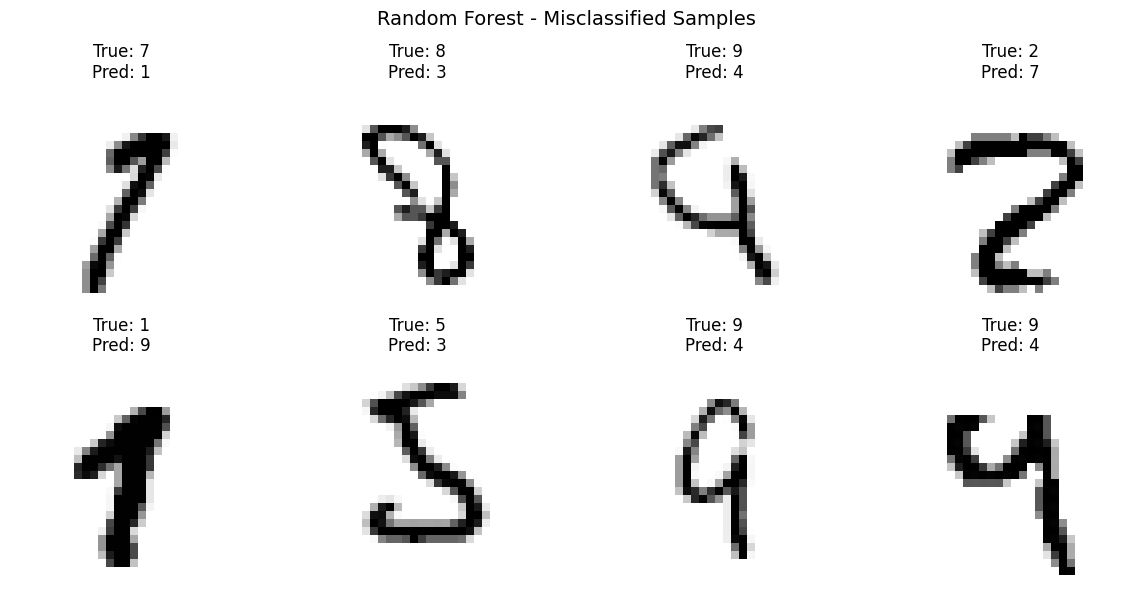

In [58]:
plot_misclassified_images(X_test, y_test, y_pred_rf, model_name='Random Forest')

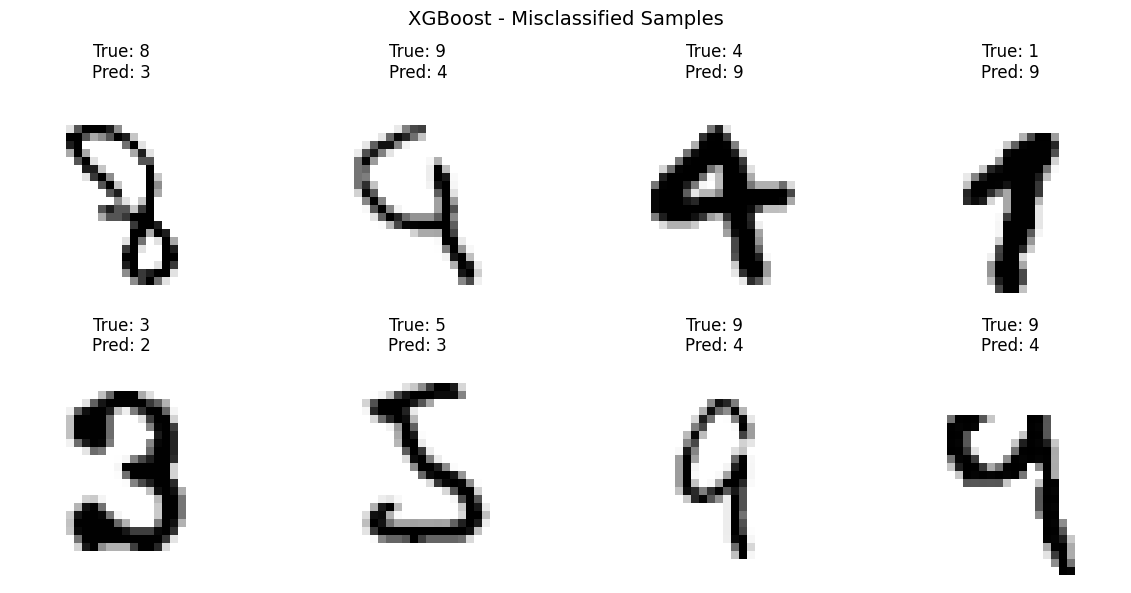

In [59]:
plot_misclassified_images(X_test, y_test, y_pred_xgb, model_name='XGBoost')

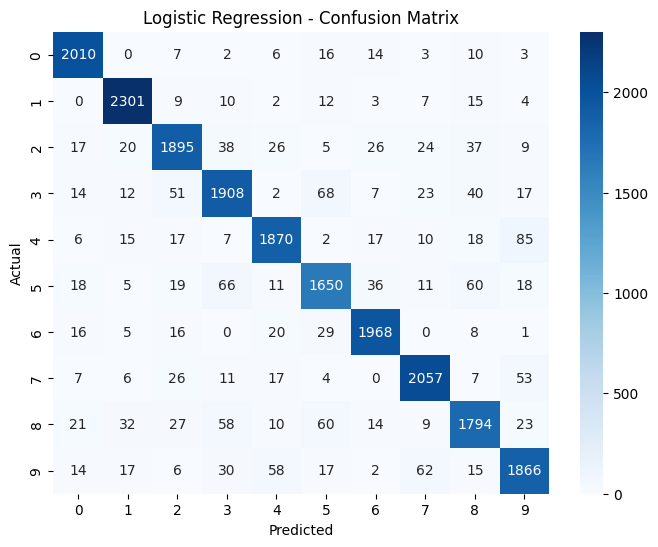

In [64]:
def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion(y_test, y_pred_logreg, 'Logistic Regression')


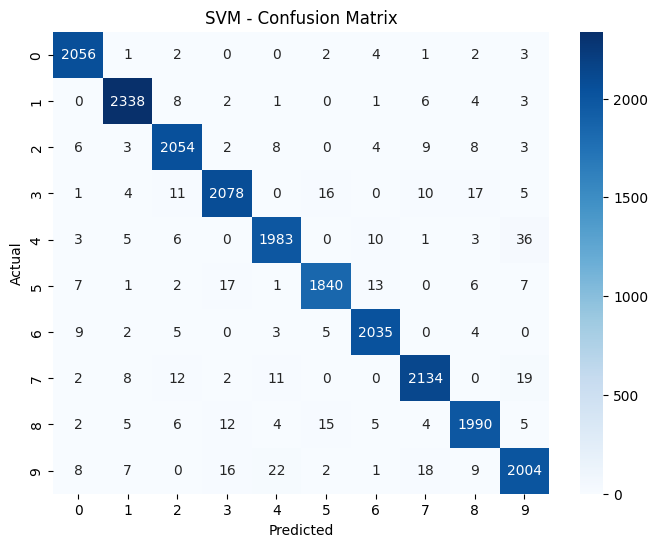

In [65]:
plot_confusion(y_test, y_pred_svm, 'SVM')

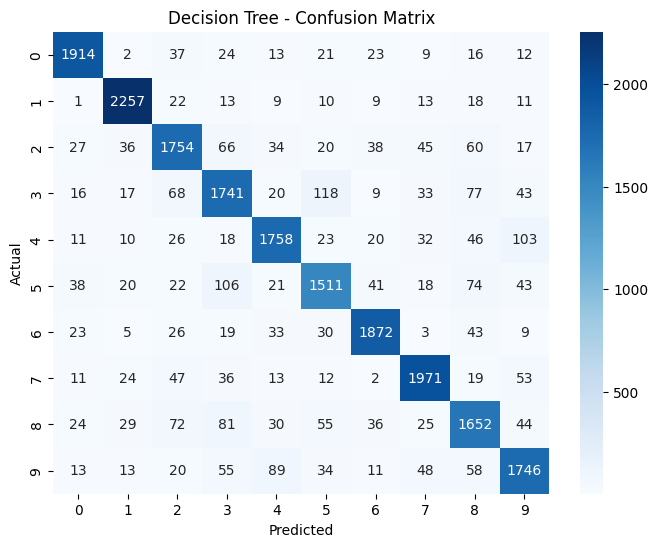

In [67]:
plot_confusion(y_test, y_pred_dt,'Decision Tree')

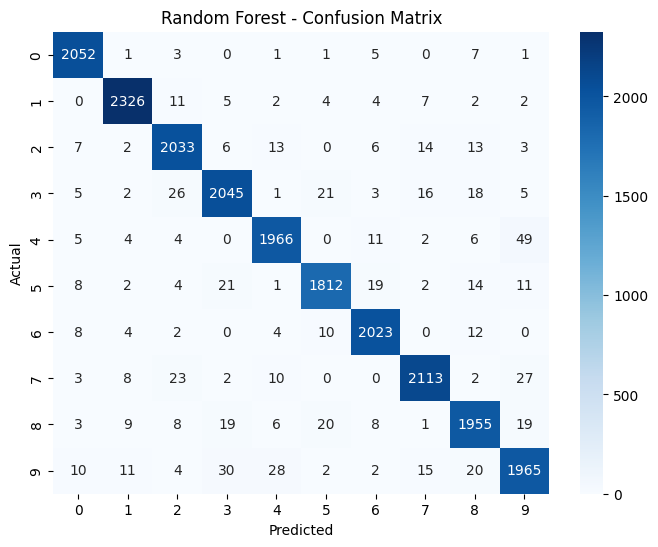

In [68]:

plot_confusion(y_test, y_pred_rf,'Random Forest')

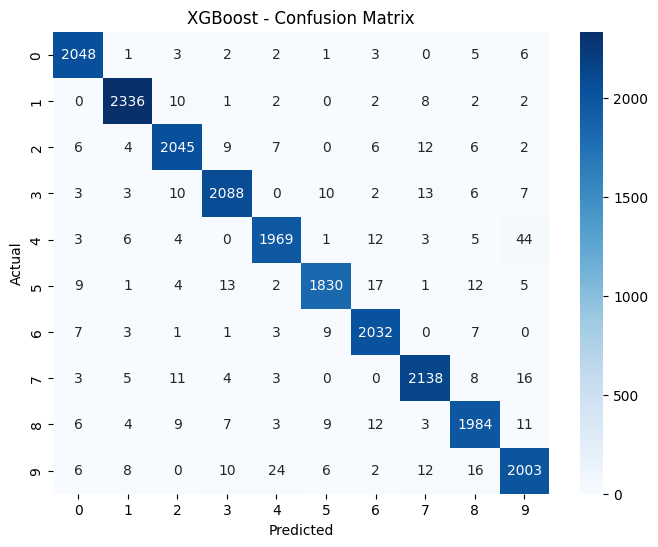

In [69]:

plot_confusion(y_test, y_pred_xgb,'XGBoost')